# Figure of Merit

Code which tasks the network to predict many (atleast $10^2$) synthethic processes, then extracts some statistics out of that

In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt
from neuralnet import mse_cyclic, loadData, mapFidLoss
import math

from dataGenNew import generate_random_function, Ugen, rand_En, full_measure, compute_waveplate, full_measure_reorder
from dataGenNew import rand_nx, rand_optic
from dataGenNew import rand_ny, rand_nz

import tensorflow as tf
from keras import backend as K
import time 
import pickle as pkl


import seaborn as sns

# Class for objects which stores information about the reconstruction
# input_meas - set of input measurements (theoretical)
# output_unitary - set of output unitary parameters (theoretical)
# pred_unitary - reconstructed unitary params 
# fid - average fidelity
# polSynth - synthetic polarimetric infidelity
# mapFid - map fidelity 
class UnitaryProcess(): 
    
    def __init__ (self, input_meas, output_unitary, pred_unitary, fid, polSynth, mapFid):
        self.input_meas = input_meas
        self.output_unitary = output_unitary
        self.fid = fid
        self.pred_unitary = pred_unitary
        self.polSynth = polSynth
        self.mapFid = mapFid
    
    def get_inputMeas(self):
        return self.input_meas
    
    def get_outputUnitary(self):
        return self.output_unitary
    
    def get_fid(self):
        return self.fid
    
    def get_polSynth(self):
        return self.polSynth
    
    def get_predUnitary(self):
        return self.pred_unitary
    
    def get_mapFid(self):
        return self.mapFid
    
    
# Some requisite code to compute the metrics of interest

def fidelity(mat1,mat2):
    prod=np.trace(np.dot(np.conjugate(mat1.T),mat2))
    
    return 0.5*np.abs(prod)

def op_par(En,nx,ny,nz):
    mat=np.zeros([2,2],dtype=complex)
    
    mat[0,0]=np.cos(En) - 1j*np.sin(En)*nz
    mat[0,1]=-1j*np.sin(En)*(nx - 1j*ny)
    mat[1,0]=-1j*np.sin(En)*(nx + 1j*ny)
    mat[1,1]=np.cos(En) + 1j*np.sin(En)*nz
    
    return mat

# Introduce the map fidelity -- this now considers the (pixelwise) local phase

def map_fid(th_params, rec_params, res):
    Stot = np.zeros([2,2], dtype=complex)
    
    En_th,nx_th,ny_th, nz_th = th_params
    En_rec, nx_rec, ny_rec, nz_rec = rec_params
    
    for i in range(res):
        for j in range(res):
            U_th = op_par(En_th[i,j], nx_th[i,j], ny_th[i,j], nz_th[i,j])
            U_rec = op_par(En_rec[i,j], nx_rec[i,j], ny_rec[i,j], nz_rec[i,j])
            Stot += np.dot(np.conjugate(U_th.T), U_rec) 
            
    tot_trace = np.trace(Stot)
    
    return abs(tot_trace)/(2*res**2)


def op_par_alt(En, nx, ny, nz):   
    mat00 = np.cos(En) - 1j*np.sin(En)*nz
    mat01 = -1j*np.sin(En)*(nx - 1j*ny)
    mat10 = -1j*np.sin(En)*(nx + 1j*ny)
    mat11 =  np.cos(En) + 1j*np.sin(En)*nz    
    
    return mat00, mat01, mat10, mat11


def get_full_pixelwise(N):
    part00 =  np.full((N, N, 2,2), [[1,0],[0,0]])
    part01 =  np.full((N, N, 2,2), [[0,1],[0,0]])
    part10 =  np.full((N, N, 2,2), [[0,0],[1,0]])
    part11 =  np.full((N, N, 2,2), [[0,0],[0,1]])    
    
    return part00, part01, part10, part11


First, let's load the trained model

In [3]:
# Load model checkpoint 

num_pix = 64

your_model = '' # Specify name of your trained model

loaded_model = tf.keras.models.load_model(f'models/{your_model}', custom_objects={'math': math, 'mse_cyclic_2':mse_cyclic_2, 'mapFidLoss_2': mapFidLoss_2}, compile=True)

Specify some parameters to produce the figure of merit

In [35]:
res = num_pix # resolution of image
maxAng = 5 # maximum angle by which the process is rotated
noise = 0.00 # sigma for gaussian noise
stateNoise = 0.0 # upper bound of noise applied on the state
num_of_process = 1000 # number of processes to consider

isPlate = False # Do we consider a process that includes single optical waveplates
sixMeasure = True # Do we consider six measurements as input? 


# Computing the Figure of Merit from an External Dataset

First, load the dataset

In [36]:
ext_dataset = '' # name of external dataset goes here

with open(f'64by64_10k_sixMeasure_test.pkl', 'rb') as f:
    X,y = pkl.load(f)
    
dataset_name = "sixmeasure" # assigned name of case considered

Using data from the external dataset, reconstruct num_of_process processes

In [39]:
samples = []
times = []

for ii in range(num_of_process):
    print("************")
    # Load theoretical process
    
    full_meas = X[ii,:,:,:]
    a1 = y[ii,:,:,0]
    a2 = y[ii,:,:,1]
    a3 = y[ii,:,:,2]
    full_meas_enhance = tf.expand_dims(full_meas, axis=0)

    # Now, perform measurement
    
    start_time = time.time()
    y_pred=loaded_model.predict(full_meas_enhance)
    fin_time = time.time() - start_time 
    times.append(fin_time)
    
    print(f'Finished! Approximate compute time is {fin_time}')
    
    a1_expt = y_pred[0,:,:,0]
    a2_expt = y_pred[0,:,:,1]
    a3_expt = y_pred[0,:,:,2]
        
    # Polar coordinate reconstruction
    
    En_vect=a1_expt
    nx_vect=np.sin(a2_expt)*np.cos(a3_expt)
    ny_vect=np.sin(a2_expt)*np.sin(a3_expt)
    nz_vect=np.cos(a2_expt)
    
    nx=np.sin(a2)*np.cos(a3)
    ny=np.sin(a2)*np.sin(a3)
    nz=np.cos(a2)
    
     
    # Return the matrix entry elems of the usual 2 x 2 unitary
    
    mat00_th, mat01_th, mat10_th, mat11_th = op_par_alt(a1,nx,ny,nz)
    mat00_exp, mat01_exp, mat10_exp, mat11_exp = op_par_alt(En_vect, nx_vect, ny_vect, nz_vect)# Let's define a new matrix with the elements that we want (for both theory and expt)
    Uth_part00, Uth_part01, Uth_part10, Uth_part11 = get_full_pixelwise(num_pix)
    Uexp_part00, Uexp_part01, Uexp_part10, Uexp_part11 = get_full_pixelwise(num_pix)# Now, perform elementwise multiplication. Same with expt
    Uth_complete = Uth_part00 * mat00_th[:,:,None,None] + Uth_part01 * mat01_th[:,:,None,None] + Uth_part10 * mat10_th[:,:,None,None]  + Uth_part11 * mat11_th[:,:,None,None]
    Uexp_complete = Uexp_part00 * mat00_exp[:,:,None,None] + Uexp_part01 * mat01_exp[:,:,None,None] + Uexp_part10 * mat10_exp[:,:,None,None]  + Uexp_part11 * mat11_exp[:,:,None,None]
    
    # compute the map fidelity
    mat1 = np.conjugate(np.transpose(Uth_complete, (0,1,3,2)))
    mat2 = Uexp_complete
    prod = mat1 @ mat2
    
    Stot = np.sum(prod, axis=(0,1))
    tot_trace = np.trace(Stot)
    mapFid= abs(tot_trace)/(2*res**2)
    meanFid = np.mean(0.5*np.abs(np.trace(prod, axis1=2, axis2=3)))
    
    # Report the average fidelity and map fidelity
    
    print(f"Average Fidelity: {meanFid}")
    print(f"Map Fidelity: {mapFid}")
    
    # Compute the polametric infidelity
    
    full_meas_synth = full_measure(a1_expt, a2_expt, a3_expt, res, noise, stateNoise, sixMeasure=sixMeasure)
    polSynth = 1 - np.square(np.subtract(full_meas,full_meas_synth)).mean()
    
    # Instantiate a new 'UnitaryProcess' object and store the unitary parameter, as well as statistics of the reconstruction, there
    
    unitProcess = UnitaryProcess(input_meas=X[ii], output_unitary=y[ii], fid=meanFid, pred_unitary=np.array([a1_expt,a2_expt,a3_expt]), polSynth=polSynth, mapFid = mapFid)
    
    samples.append(unitProcess)
    print(f'Finished process {ii}')
    print("************")


************
1/1 [==============================] - 0s 201ms/step
Finished! Approximate compute time is 0.25687074661254883
Average Fidelity: 0.9721192518072548
Map Fidelity: 0.9700469356926678
Finished process 0
************
************
1/1 [==============================] - 0s 211ms/step
Finished! Approximate compute time is 0.27535486221313477
Average Fidelity: 0.8599633412132822
Map Fidelity: 0.7049316219514238
Finished process 1
************
************
1/1 [==============================] - 0s 192ms/step
Finished! Approximate compute time is 0.24000263214111328
Average Fidelity: 0.9740622500758065
Map Fidelity: 0.9734550634545263
Finished process 2
************
************
1/1 [==============================] - 0s 186ms/step
Finished! Approximate compute time is 0.22603964805603027
Average Fidelity: 0.9712390952124416
Map Fidelity: 0.9712390952124412
Finished process 3
************
************
1/1 [==============================] - 0s 156ms/step
Finished! Approximate compute 

1/1 [==============================] - 0s 149ms/step
Finished! Approximate compute time is 0.18000030517578125
Average Fidelity: 0.9581739697070397
Map Fidelity: 0.9570231871610679
Finished process 72
************
************
1/1 [==============================] - 0s 146ms/step
Finished! Approximate compute time is 0.1829993724822998
Average Fidelity: 0.8655677614321571
Map Fidelity: 0.5731891145169646
Finished process 73
************
************
1/1 [==============================] - 0s 161ms/step
Finished! Approximate compute time is 0.19100332260131836
Average Fidelity: 0.901070279555623
Map Fidelity: 0.39870376801371343
Finished process 74
************
************
1/1 [==============================] - 0s 154ms/step
Finished! Approximate compute time is 0.182542085647583
Average Fidelity: 0.9778259101503849
Map Fidelity: 0.9778259101503871
Finished process 75
************
************
1/1 [==============================] - 0s 153ms/step
Finished! Approximate compute time is 0.18

1/1 [==============================] - 0s 144ms/step
Finished! Approximate compute time is 0.1750030517578125
Average Fidelity: 0.9220920689796108
Map Fidelity: 0.921541502674774
Finished process 144
************
************
1/1 [==============================] - 0s 158ms/step
Finished! Approximate compute time is 0.1925945281982422
Average Fidelity: 0.963741620130825
Map Fidelity: 0.9636024309299295
Finished process 145
************
************
1/1 [==============================] - 0s 153ms/step
Finished! Approximate compute time is 0.18367600440979004
Average Fidelity: 0.962046032178651
Map Fidelity: 0.9618024623051644
Finished process 146
************
************
1/1 [==============================] - 0s 142ms/step
Finished! Approximate compute time is 0.17200446128845215
Average Fidelity: 0.9501240227224497
Map Fidelity: 0.9395834066034339
Finished process 147
************
************
1/1 [==============================] - 0s 158ms/step
Finished! Approximate compute time is 0.

1/1 [==============================] - 0s 141ms/step
Finished! Approximate compute time is 0.17275381088256836
Average Fidelity: 0.943590655932601
Map Fidelity: 0.9412667147248458
Finished process 216
************
************
1/1 [==============================] - 0s 145ms/step
Finished! Approximate compute time is 0.17999887466430664
Average Fidelity: 0.9639016557000637
Map Fidelity: 0.9639016557000638
Finished process 217
************
************
1/1 [==============================] - 0s 146ms/step
Finished! Approximate compute time is 0.1759953498840332
Average Fidelity: 0.9752661424658841
Map Fidelity: 0.975176311910307
Finished process 218
************
************
1/1 [==============================] - 0s 149ms/step
Finished! Approximate compute time is 0.17899775505065918
Average Fidelity: 0.9866599942840304
Map Fidelity: 0.9866599942840303
Finished process 219
************
************
1/1 [==============================] - 0s 150ms/step
Finished! Approximate compute time is 

1/1 [==============================] - 0s 133ms/step
Finished! Approximate compute time is 0.16281509399414062
Average Fidelity: 0.9647888189198045
Map Fidelity: 0.9575327434794767
Finished process 288
************
************
1/1 [==============================] - 0s 142ms/step
Finished! Approximate compute time is 0.17597341537475586
Average Fidelity: 0.9214413224956737
Map Fidelity: 0.07581405464873327
Finished process 289
************
************
1/1 [==============================] - 0s 141ms/step
Finished! Approximate compute time is 0.1699848175048828
Average Fidelity: 0.9654281528166253
Map Fidelity: 0.9532043009805714
Finished process 290
************
************
1/1 [==============================] - 0s 128ms/step
Finished! Approximate compute time is 0.15774774551391602
Average Fidelity: 0.9614714405265076
Map Fidelity: 0.9484525116154207
Finished process 291
************
************
1/1 [==============================] - 0s 132ms/step
Finished! Approximate compute time 

...

1/1 [==============================] - 0s 143ms/step
Finished! Approximate compute time is 0.17397451400756836
Average Fidelity: 0.9109553967413808
Map Fidelity: 0.7856613239173766
Finished process 684
************
************
1/1 [==============================] - 0s 141ms/step
Finished! Approximate compute time is 0.17498111724853516
Average Fidelity: 0.9328536281572595
Map Fidelity: 0.8735983513204408
Finished process 685
************
************
1/1 [==============================] - 0s 136ms/step
Finished! Approximate compute time is 0.1659858226776123
Average Fidelity: 0.9633605760929945
Map Fidelity: 0.9633564871103408
Finished process 686
************
************
1/1 [==============================] - 0s 131ms/step
Finished! Approximate compute time is 0.16300559043884277
Average Fidelity: 0.9696801505430797
Map Fidelity: 0.9696801505430777
Finished process 687
************
************
1/1 [==============================] - 0s 135ms/step
Finished! Approximate compute time i

1/1 [==============================] - 0s 239ms/step
Finished! Approximate compute time is 0.2989652156829834
Average Fidelity: 0.9657541420105036
Map Fidelity: 0.9657541420105038
Finished process 720
************
************
1/1 [==============================] - 0s 247ms/step
Finished! Approximate compute time is 0.3195502758026123
Average Fidelity: 0.9550320285532898
Map Fidelity: 0.9409825695320966
Finished process 721
************
************
1/1 [==============================] - 0s 240ms/step
Finished! Approximate compute time is 0.3089745044708252
Average Fidelity: 0.928172796851964
Map Fidelity: 0.9281727968519633
Finished process 722
************
************
1/1 [==============================] - 0s 222ms/step
Finished! Approximate compute time is 0.2853047847747803
Average Fidelity: 0.9569012207718495
Map Fidelity: 0.9569012207718511
Finished process 723
************
************
1/1 [==============================] - 0s 218ms/step
Finished! Approximate compute time is 0.

1/1 [==============================] - 0s 220ms/step
Finished! Approximate compute time is 0.2856602668762207
Average Fidelity: 0.9703967471024475
Map Fidelity: 0.9679525809220814
Finished process 792
************
************
1/1 [==============================] - 0s 247ms/step
Finished! Approximate compute time is 0.3159651756286621
Average Fidelity: 0.9346925284520118
Map Fidelity: 0.9049739141697848
Finished process 793
************
************
1/1 [==============================] - 0s 225ms/step
Finished! Approximate compute time is 0.2909736633300781
Average Fidelity: 0.9854340935523488
Map Fidelity: 0.9854340935523466
Finished process 794
************
************
1/1 [==============================] - 0s 250ms/step
Finished! Approximate compute time is 0.31099700927734375
Average Fidelity: 0.9613212191643368
Map Fidelity: 0.9438899516255893
Finished process 795
************
************
1/1 [==============================] - 0s 241ms/step
Finished! Approximate compute time is 

1/1 [==============================] - 0s 220ms/step
Finished! Approximate compute time is 0.2777678966522217
Average Fidelity: 0.9683059438188031
Map Fidelity: 0.9681068828938292
Finished process 864
************
************
1/1 [==============================] - 0s 208ms/step
Finished! Approximate compute time is 0.2879753112792969
Average Fidelity: 0.9769841493278828
Map Fidelity: 0.9760408829210829
Finished process 865
************
************
1/1 [==============================] - 0s 233ms/step
Finished! Approximate compute time is 0.29462575912475586
Average Fidelity: 0.9369907325860928
Map Fidelity: 0.897575240752232
Finished process 866
************
************
1/1 [==============================] - 0s 250ms/step
Finished! Approximate compute time is 0.3139779567718506
Average Fidelity: 0.9693149925187623
Map Fidelity: 0.9686716677942006
Finished process 867
************
************
1/1 [==============================] - 0s 242ms/step
Finished! Approximate compute time is 0

1/1 [==============================] - 0s 252ms/step
Finished! Approximate compute time is 0.3076362609863281
Average Fidelity: 0.9792754530336556
Map Fidelity: 0.9792754530336535
Finished process 936
************
************
1/1 [==============================] - 0s 217ms/step
Finished! Approximate compute time is 0.28755927085876465
Average Fidelity: 0.9635321552586986
Map Fidelity: 0.9631853209005574
Finished process 937
************
************
1/1 [==============================] - 0s 234ms/step
Finished! Approximate compute time is 0.2959940433502197
Average Fidelity: 0.9353890178044245
Map Fidelity: 0.5938091045765382
Finished process 938
************
************
1/1 [==============================] - 0s 245ms/step
Finished! Approximate compute time is 0.31799960136413574
Average Fidelity: 0.9745136330714196
Map Fidelity: 0.9745136330714198
Finished process 939
************
************
1/1 [==============================] - 0s 238ms/step
Finished! Approximate compute time is

Save the map fidelities and polarimetric fidelities in case we need to replot the histograms ... don't want to do the experiment again

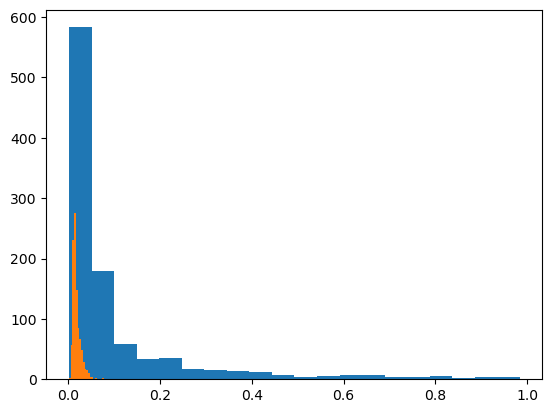

In [41]:
fids = [samples[ii].get_fid() for ii in range(len(samples))]
polInfids = [1 - samples[ii].polSynth for ii in range(len(samples))]
mapFids = [samples[ii].get_mapFid() for ii in range(len(samples))]
oneMinusMapFids = [1- mapFid for mapFid in mapFids]

totalFids = np.array([fids, polInfids, mapFids])

with open(f"histogram_data/mapFid_{dataset_name}.pkl", "wb") as f:
    pkl.dump(totalFids, f)


Load the computed metrics for future computation and comparision

In [47]:
# Directory names for fidelity distributions (1) before and (2) after two-step training

dataset_name_1 = '' # Insert first dataset name here
dataset_name_2 = '' # Insert second dataset name here 

with open(f"histogram_data/{dataset_name_1}.pkl", "rb") as f1:
    totalFids1 = pkl.load(f1)
    
with open(f"histogram_data/{dataset_name_2}.pkl", "rb") as f2:
    totalFids2 = pkl.load(f2)
    
fids = totalFids1[0]
polInfids = totalFids1[1]
mapFids = totalFids1[2]

fids_biased = totalFids2[0]
polInfids_biased = totalFids2[1]
mapFids_biased = totalFids2[2]

#oneMinusFids = [1 - fid for fid in fids]
oneMinusSynth = [polInfid for polInfid in polInfids]
oneMinusMapFids = [1- mapFid for mapFid in mapFids]


oneMinusMapFids_biased = [1 - mapFid for mapFid in mapFids_biased]
oneMinusSynth_biased = [polSynth for polSynth in polInfids_biased]

hist,bins1,_ = plt.hist(oneMinusMapFids, bins=20)
hist2,bins2,_ = plt.hist(oneMinusSynth, bins=20)


Plot overlapping histograms

[None, None, None, None]

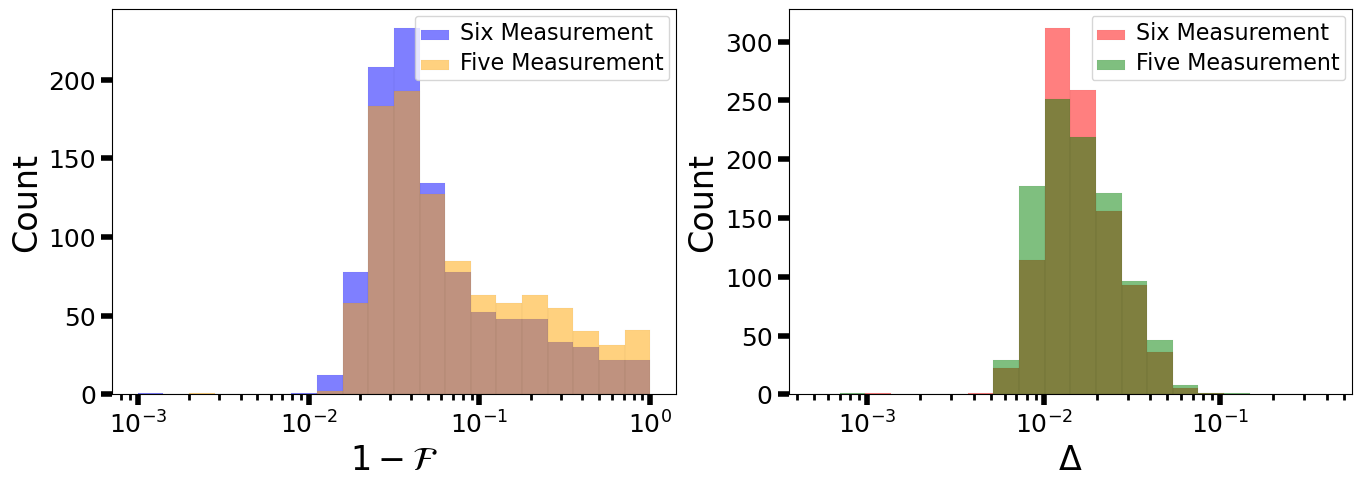

In [49]:
# take the log of the bins

logbins1 = np.logspace(np.log10(1e-3),0, len(bins1))
logbins2 = np.logspace(np.log10(5e-4), np.log10(4e-1), len(bins2))

# Now do the plotting things

fig,ax = plt.subplots(1,2, figsize=(16,5))

hicky = sns.histplot(oneMinusSynth, bins=logbins2, ax = ax[1], color='red', alpha=0.5, label='Six Measurement')
hicky_biased = sns.histplot(oneMinusSynth_biased, bins=logbins2, ax = ax[1], color='green', alpha=0.5, label='Five Measurement')
ax[1].set_xscale('log') 
ax[1].set_xlabel(r"$\Delta$", fontsize='24')
ax[1].set_ylabel('Count', fontsize='24')
ax[1].tick_params(which='major', width=4, length=8, labelsize=18)
ax[1].tick_params(which='minor', width=2, length=4)
ax[1].legend(prop={'size': 10}, fontsize='18')
plt.setp(ax[1].get_legend().get_texts(), fontsize='16') # for legend text

sicky = sns.histplot(oneMinusMapFids, bins=logbins1, ax = ax[0], color='blue', alpha=0.5, label='Six Measurement')
sicky_biased = sns.histplot(oneMinusMapFids_biased, bins=logbins1, ax = ax[0], color='orange', alpha=0.5, label='Five Measurement')
ax[0].set_xscale('log') 
ax[0].set_xlabel(r"$1-\mathcal{F}$", fontsize='24')
ax[0].set_ylabel('Count', fontsize='24')
#ax[0].set_ylim(0,5)
ax[0].locator_params(axis='y', integer=True)
ax[0].tick_params(which='major', width=4, length=8, labelsize=18)
ax[0].tick_params(which='minor', width=2, length=4)
ax[0].legend(prop={'size': 10}, fontsize='24')
plt.setp(ax[0].get_legend().get_texts(), fontsize='16') # for legend text

#plt.savefig('figureOfMerit_twoStep_Waveplates_update.pdf', bbox_inches='tight')

# Comparision with Genetic Algorithm 

Load reconstructions from the genetic algorithm 

In [7]:
with open(f'predUnits_fiveGA_withNoise.pkl', 'rb') as f:
    y_GA = pkl.load(f)
    
y_GA[0][0].shape

isGA = True

FileNotFoundError: [Errno 2] No such file or directory: 'predUnits_fiveGA_withNoise.pkl'

Compute the map fidelity and polarimetric infidelity for each GA-reconstructed process

In [45]:
if(isGA):
    mapFids_GA = []
    meanFid_GA = []

else:
    mapFids = []
    polInfids = []

shift = 0 
    
for ii in range(num_of_process):
    print("************")
    
    # Load theoretical process

    a1 = y[ii+shift,:,:,0]
    a2 = y[ii+shift,:,:,1]
    a3 = y[ii+shift,:,:,2]
    
    nx=np.sin(a2)*np.cos(a3)
    ny=np.sin(a2)*np.sin(a3)
    nz=np.cos(a2)
    
    # Compute unitary 
    
    mat00_th, mat01_th, mat10_th, mat11_th = op_par_alt(a1,nx,ny,nz)
    Uth_part00, Uth_part01, Uth_part10, Uth_part11 = get_full_pixelwise(num_pix) 
    Uth_complete = Uth_part00 * mat00_th[:,:,None,None] + Uth_part01 * mat01_th[:,:,None,None] + Uth_part10 * mat10_th[:,:,None,None]  + Uth_part11 * mat11_th[:,:,None,None]
    
    # Load expt process
    
    if(isGA):
        Uexp_complete = y_GA[ii]
    else:
        a1_expt, a2_expt, a3_expt = y_GA[ii][0], y_GA[ii][1], y_GA[ii][2]

        nx_expt=np.sin(a2_expt)*np.cos(a3_expt)
        ny_expt=np.sin(a2_expt)*np.sin(a3_expt)
        nz_expt=np.cos(a2_expt)

        # Compute the experimental unitary

        mat00_exp, mat01_exp, mat10_exp, mat11_exp = op_par_alt(a1_expt, nx_expt, ny_expt, nz_expt)

        Uexp_part00, Uexp_part01, Uexp_part10, Uexp_part11 = get_full_pixelwise(num_pix) 
        Uexp_complete = Uexp_part00 * mat00_exp[:,:,None,None] + Uth_part01 * mat01_exp[:,:,None,None] + Uexp_part10 * mat10_exp[:,:,None,None]  + Uexp_part11 * mat11_exp[:,:,None,None]
    
    
    # compute the map fidelity
    
    # The unitaries are computed in the same way
    mat1 = np.conjugate(np.transpose(Uth_complete, (0,1,3,2)))
    mat2 = Uexp_complete
    prod = mat1 @ mat2
    
    Stot = np.sum(prod, axis=(0,1))
    tot_trace = np.trace(Stot)
    mapFid= abs(tot_trace)/(2*res**2)
    meanFid=np.mean(0.5*np.abs(np.trace(prod, axis1=2, axis2=3)))
    
    if (isGA==False):
        full_meas = X[ii,:,:,:]
        full_meas_synth = full_measure(a1_expt, a2_expt, a3_expt, res, noise, stateNoise)
        polSynth = np.square(np.subtract(full_meas,full_meas_synth)).mean()
        polInfids.append(polSynth)
        
    
    print(f"Average Fidelity: {meanFid}")
    print(f"Map Fidelity: {mapFid}")
    
    if(isGA):
        mapFids_GA.append(mapFid)
        meanFid_GA.append(meanFid)
    else:
        mapFids.append(mapFid)
    
    print(f'Finished process {ii}')
    print("************")


************
Average Fidelity: 0.9983251001435972
Map Fidelity: 0.9885829117181338
Finished process 0
************
************
Average Fidelity: 0.9970612579690148
Map Fidelity: 0.995111896718054
Finished process 1
************
************
Average Fidelity: 0.9911025666521996
Map Fidelity: 0.3702881361635971
Finished process 2
************
************
Average Fidelity: 0.9724601644056922
Map Fidelity: 0.8671994716406832
Finished process 3
************
************
Average Fidelity: 0.9972438783238717
Map Fidelity: 0.971382775318367
Finished process 4
************
************
Average Fidelity: 0.9980814898781873
Map Fidelity: 0.9927130163168935
Finished process 5
************
************
Average Fidelity: 0.996201103168183
Map Fidelity: 0.9150618209515687
Finished process 6
************
************
Average Fidelity: 0.996782184024896
Map Fidelity: 0.996782184024896
Finished process 7
************
************
Average Fidelity: 0.9955860527946279
Map Fidelity: 0.9611445306395618
Fi

Now, do an overlap between the GA results and the NN results. 

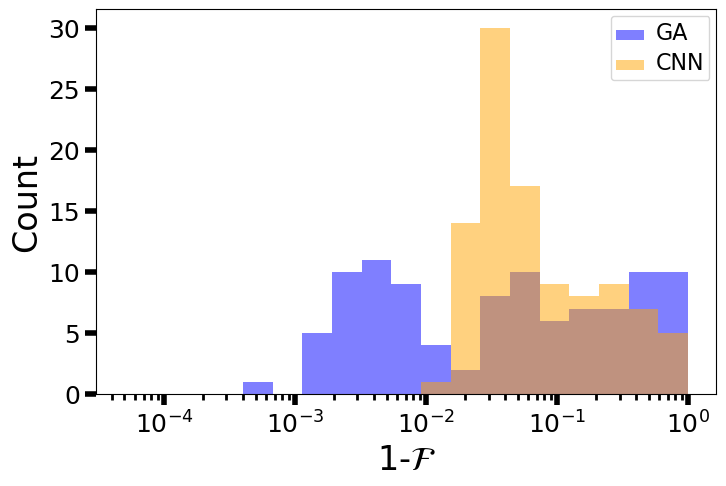

In [50]:
oneMinusMapFids_GA = [1-mapFid for mapFid in mapFids_GA]
oneMinusMapFids_CNN = oneMinusMapFids[0:100]

# take the log of the bins

logbins1 = np.logspace(np.log10(5e-5),0, 20)

fig,ax = plt.subplots(1,1, figsize=(8, 5))

rocky = sns.histplot(oneMinusMapFids_GA, bins=logbins1, ax=ax, alpha=0.5, color='blue', label='GA')
socky = sns.histplot(oneMinusMapFids_CNN, bins=logbins1, ax=ax,  alpha=0.5, color='orange', label='CNN')

ax.set_xscale('log') 
ax.set_xlabel(r"1-$\mathcal{F}$", fontsize='24')
ax.set_ylabel('Count', fontsize='24')
ax.set_xlim()
ax.locator_params(axis='y', integer=True)
plt.legend(prop={'size': 10})
plt.setp(ax.get_legend().get_texts(), fontsize='16') # for legend text
ax.tick_params(which='major', width=4, length=8, labelsize=18)
ax.tick_params(which='minor', width=2, length=4)

plt.savefig("Ga_vs_CNN_withNoise_firstDraft.pdf", format='pdf', bbox_inches='tight')


Make an inset scatter plot between the map and mean fidelities

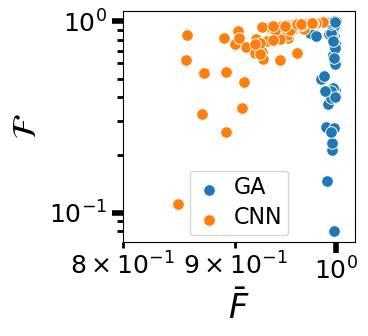

In [49]:

fig,ax = plt.subplots(1,1, figsize=(3, 3))

floffy = sns.scatterplot(y=mapFids_GA, x=meanFid_GA, ax=ax, label='GA', s=70)
doffy = sns.scatterplot(y=mapFids, x=fids, ax=ax, label='CNN', s=70)
plt.legend(prop={'size': 10}, fontsize='42')
ax.set_ylabel(r'$\mathcal{F}$', fontsize='24')
ax.set_xlabel(r'$\bar{F}$', fontsize='24')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(8e-1,1.02e0)
ax.tick_params(which='major', width=4, length=8, labelsize='18')
ax.tick_params(which='minor', width=2, length=4, labelsize='18')
plt.setp(ax.get_legend().get_texts(), fontsize='16') # for legend text
#ax.tick_params(axis='x', which='minor', labelbottom=False)

plt.savefig("Ga_vs_CNN_withNoise_scatter_firstDraft.pdf", format='pdf', bbox_inches='tight')